# 1.0 Import Data

In [2]:
# %%capture
!pip -q install torchinfo

In [3]:
# Import Library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchinfo import summary
import torchvision.transforms.functional as F

# Scikit-learn imports
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report

# Additional utilities
import random

# Check GPU availability
if torch.cuda.is_available():
    device = 'cuda'
else:
    device = 'cpu'

In [4]:
train_df = pd.read_csv('keypoint_train_data.csv')
valid_df = pd.read_csv('keypoint_valid_data.csv')
test_df = pd.read_csv('keypoint_test_data.csv')

# 2.0 Data Preprocessing

Helper Function, class

In [5]:
def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

In [6]:
class SittingPosture(Dataset):
    def __init__(self, data, label):
      self.X = torch.tensor(data, dtype=torch.float32)
      self.y = torch.tensor(label, dtype=torch.long)

    def __len__(self):
      return len(self.X)

    def __getitem__(self, idx):
      X, y = self.X[idx], self.y[idx]
      return X, y

#### Data Preprocessing

In [7]:
def minmax_normalise(df, variations: str, scaler=None, is_train: bool=True):

    df_normalized = df.copy()
    
    coord_cols = df_normalized.columns.drop(['image_id', 'cat_id'])

    ####################################
    # Generated from Gemini
    ####################################
    visibility_cols = [col for col in coord_cols if col.endswith('_v')]
    xy_cols = [col for col in coord_cols if not col.endswith('_v')]
    ####################################
    # End
    ####################################

    for visibility_col in visibility_cols:
        col_name = visibility_col.replace('_v', '')
        X_col = f"{col_name}_x"
        y_col = f"{col_name}_y"
        
        # Mask here contains boolean of each row whether if visibility_col[i] is 0.0
        mask = df_normalized[visibility_col] == 0.0
        df_normalized.loc[mask, [X_col, y_col]] = np.nan

    if variations=="col_wise":
        print("Using MinMaxScaler")
        if is_train:
            scaler = MinMaxScaler()
            df_normalized[xy_cols] = scaler.fit_transform(df_normalized[xy_cols])
            
        else:
            if scaler is None:
                print("No scaler given!")
            
            df_normalized[xy_cols] = scaler.transform(df_normalized[xy_cols])
        
    elif variations=="row_wise":
        print("Using minmax_scale")
        scaled_array = minmax_scale(df_normalized[xy_cols], axis=1)
        df_normalized[xy_cols] = scaled_array
    
    df_normalized[xy_cols] = df_normalized[xy_cols].fillna(0.0)

    if variations=="col_wise" and is_train:
        return df_normalized, scaler
    else:
        return df_normalized

In [8]:
def manual_normalisation(df):
    """
    Wraps the PyTorch normalize_coco_posture function to work on a Pandas DataFrame.
    """
    df_normalized = df.copy()
    coord_cols = df_normalized.columns.drop(['image_id', 'cat_id'])

    # Iterate through the DataFrame row by row
    for index, row in df_normalized.iterrows():
        # 1. Extract the 51 flat coordinates as a numpy array
        raw_coords = row[coord_cols].values.astype(np.float32)
        
        # 2. Convert to Tensor and reshape to [17 nodes, 3 features (X,Y,V)]
        tensor_coords = torch.tensor(raw_coords).view(17, 3)
        
        # 3. Apply your custom geometric normalizer
        normalized_tensor = normalize_coco_posture_safe(tensor_coords)
        
        # 4. Flatten the [17, 3] tensor back into a flat 51-element 1D array
        flat_normalized_coords = normalized_tensor.view(-1).numpy()
        
        # 5. Inject the newly normalized coordinates back into the DataFrame
        df_normalized.loc[index, coord_cols] = flat_normalized_coords
        
    return df_normalized

def normalize_coco_posture_safe(pos_tensor):
    """
    Safely normalizes a [17, 3] COCO keypoint tensor using the Visibility flag.
    """
    # 1. Split the tensor into Coordinates and Visibility
    coords = pos_tensor[:, :2].clone() # [17, 2]
    vis = pos_tensor[:, 2].clone()     # [17]
    
    # Create a Boolean Mask based explicitly on the new visibility flag
    valid_mask = vis > 0.0 
    
    # If the skeleton is entirely missing (all visibility 0), return as-is
    if not valid_mask.any():
        return pos_tensor

    # 2. Safe Mid-Hip Calculation with Fallbacks
    l_hip_valid = valid_mask[11].item()
    r_hip_valid = valid_mask[12].item()
    
    if l_hip_valid and r_hip_valid:
        root = (coords[11] + coords[12]) / 2.0
    elif l_hip_valid:
        root = coords[11]  # Fallback to Left Hip only
    elif r_hip_valid:
        root = coords[12]  # Fallback to Right Hip only
    else:
        # Emergency Fallback: If both hips are missing, try Shoulders (5, 6)
        l_sho_valid = valid_mask[5].item()
        r_sho_valid = valid_mask[6].item()
        if l_sho_valid and r_sho_valid:
            root = (coords[5] + coords[6]) / 2.0
        else:
            root = torch.tensor([0.0, 0.0], device=coords.device)

    # 3. Apply Centering ONLY to valid points
    # The missing 0.0 points remain safely dead at the origin
    coords[valid_mask] = coords[valid_mask] - root
    
    # 4. Aspect-Preserving Scale ONLY on valid points
    min_vals = coords[valid_mask].min(dim=0)[0]
    max_vals = coords[valid_mask].max(dim=0)[0]
    ranges = max_vals - min_vals
    global_scale = ranges.max()
    
    # Scale valid points. Add epsilon to prevent division by zero
    coords[valid_mask] = coords[valid_mask] / (global_scale + 1e-6)
    
    # 5. Recombine the normalized coordinates with the untouched visibility column
    # We use unsqueeze(1) to turn vis back from [17] to [17, 1] for concatenation
    final_tensor = torch.cat([coords, vis.unsqueeze(1)], dim=1)
    
    return final_tensor

In [9]:
#Split X_train, y_train
X_train = manual_normalisation(train_df)
X_train = X_train.drop(['image_id', 'cat_id'],axis=1)
y_train = train_df['cat_id']
X_valid = manual_normalisation(valid_df)
X_valid = X_valid.drop(['image_id', 'cat_id'],axis=1)
y_valid = valid_df['cat_id']
X_test = manual_normalisation(test_df)
X_test = X_test.drop(['image_id', 'cat_id'],axis=1)
y_test = test_df['cat_id']

# 3.0 Building Models

#### Create Datasets

In [10]:
# Change labels from (1, 2) to (0, 1)
y_train = y_train.values - 1
y_valid = y_valid.values - 1
y_test = y_test.values - 1

In [11]:
train_dataset = SittingPosture(X_train.values, y_train)
valid_dataset = SittingPosture(X_valid.values, y_valid)
test_dataset = SittingPosture(X_test.values, y_test)

In [12]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
valid_loader =  DataLoader(valid_dataset, batch_size=64, shuffle=False)
test_loader =  DataLoader(test_dataset, batch_size=64, shuffle=False)

Mini Gradient Descent

In [13]:
# Get a batch of data
x_batch, y_batch = next(iter(train_loader))
print(f"Shape of x_batch: {x_batch.shape}")
print(f"Shape of y_batch: {y_batch.shape}")
# Get a batch of data
x_valid_batch, y_valid_batch = next(iter(valid_loader))
print(f"Shape of x_batch: {x_batch.shape}")
print(f"Shape of y_batch: {y_batch.shape}")
# Get a batch of data
x_test_batch, y_test_batch = next(iter(test_loader))
print(f"Shape of x_batch: {x_batch.shape}")
print(f"Shape of y_batch: {y_batch.shape}")

Shape of x_batch: torch.Size([64, 51])
Shape of y_batch: torch.Size([64])
Shape of x_batch: torch.Size([64, 51])
Shape of y_batch: torch.Size([64])
Shape of x_batch: torch.Size([64, 51])
Shape of y_batch: torch.Size([64])


#### Fully Connected Neuron Network

##### Create FCNN

In [14]:
#Add Dropout???
class FCNN(nn.Module):
  def __init__(self):
    """
    Create a Fully Connected Neuron Network

    """
    super().__init__()
    self.layer1 = nn.Sequential(
        nn.Linear(in_features=51, out_features=128),
        nn.BatchNorm1d(128),
        nn.LeakyReLU(0.1),
        nn.Dropout(0.5),
    )
    self.layer2 = nn.Sequential(
        nn.Linear(in_features=128, out_features=64),
        nn.BatchNorm1d(64),
        nn.LeakyReLU(0.1),
        nn.Dropout(0.2)
    )
    self.layer3 = nn.Sequential(
        nn.Linear(in_features=64, out_features=32),
        nn.BatchNorm1d(32),
        nn.LeakyReLU(0.1),
        nn.Dropout(0.2)
    )
    self.outputlayer = nn.Linear(in_features=32, out_features=1)
    self.sigmoid = nn.Sigmoid()

  def forward(self, x):
    """
    To perform inference (do prediction).
    During training mode, this will construct the computational graph
    """
    # perform forward propagation and build computational graph
    x = self.layer1(x)
    x = self.layer2(x)
    x = self.layer3(x)
    x = self.outputlayer(x)
    x = self.sigmoid(x)

    return x

In [15]:
fcnn = FCNN()
print(fcnn)

FCNN(
  (layer1): Sequential(
    (0): Linear(in_features=51, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.1)
    (3): Dropout(p=0.5, inplace=False)
  )
  (layer2): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.1)
    (3): Dropout(p=0.2, inplace=False)
  )
  (layer3): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.1)
    (3): Dropout(p=0.2, inplace=False)
  )
  (outputlayer): Linear(in_features=32, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


##### Cost Function and Optimizer

In [16]:
optimizer = optim.Adam(fcnn.parameters(), lr=0.0001, weight_decay= 1e-3)
loss_function = nn.BCELoss()

# 4.0 Training the Model

Helper Function

In [ ]:
def train(train_loader, model, optimizer, loss_function, num_epochs, patience):
    # List to store epoch costs for plotting
    train_epoch_costs = []
    valid_epoch_costs = []
    train_epoch_accuracy = []
    valid_epoch_accuracy = []
    patience_count = 0
    best_val_loss = None

    # For all epochs
    for epoch in range(num_epochs):
        train_total = 0
        train_correct = 0
        train_batch_costs = []
        valid_batch_costs = []

        # set to training mode
        model.train()

        # ===== TRAIN ======
        for x_batch, y_batch in train_loader:

            # transfer batch data to the GPU if available
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            # Reshape y_batch's shape = y_hat's shape (B, 1)
            y_batch = y_batch.unsqueeze(1).float()

            # Forward propagation
            y_hat = model(x_batch) # shape = (B,1)

            # Compute cost
            cost = loss_function(y_hat, y_batch)
            train_batch_costs.append(cost.item())

            # Compute accuracy
            y_hat = y_hat.squeeze()
            y_batch = y_batch.squeeze()
            y_pred = (y_hat > 0.5).float()
            train_total   += y_batch.size(0)
            train_correct += (y_pred == y_batch).sum().item()

            # Backward propagation
            cost.backward()

            # Update parameters
            optimizer.step()

            # Reset the gradient
            optimizer.zero_grad()
        # ===== END OF TRAIN ======

        train_acc = train_correct / train_total

        total = 0
        correct = 0
        # set to evaluation mode
        model.eval()

        # ===== VALIDATION ======
        with torch.inference_mode():
          for x_batch, y_batch in valid_loader:
            
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            y_batch = y_batch.unsqueeze(1).float()

            y_hat = model(x_batch) # shape = (B,1)

            # Compute cost
            cost = loss_function(y_hat, y_batch)
            valid_batch_costs.append(cost.item())

            # Compute accuracy
            y_pred = (y_hat.squeeze() > 0.5).float()
            y_batch = y_batch.squeeze()
            total   += y_batch.size(0)
            correct += (y_pred == y_batch).sum().item()

        val_acc = correct / total
        # ===== END OF VALIDATION ======

        # Calculate average cost/avg for the epoch
        avg_train_epoch_cost = sum(train_batch_costs) / len(train_batch_costs)
        avg_valid_epoch_cost = sum(valid_batch_costs) / len(valid_batch_costs)
        train_epoch_costs.append(avg_train_epoch_cost)
        valid_epoch_costs.append(avg_valid_epoch_cost)
        train_epoch_accuracy.append(train_acc)
        valid_epoch_accuracy.append(val_acc)

        if (epoch + 1) % (num_epochs//10) == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], average train cost: {avg_train_epoch_cost:.4f}, average val cost: {avg_valid_epoch_cost:.4f}, average train accuracy: {train_acc:.4f}, average val accuracy: {val_acc:.4f}")

        if best_val_loss is None or avg_valid_epoch_cost < best_val_loss:
          best_val_loss = avg_valid_epoch_cost
          torch.save(model.state_dict(), 'best_model.pth')
          patience_count = 0
        else:
            patience_count += 1
            if patience_count >= patience:
              break
    # Plotting the cost
    actual_epochs = len(train_epoch_costs)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    ax1.plot(train_epoch_costs, label='Training Loss')
    ax1.plot(valid_epoch_costs, label='Validation Loss', linestyle='--')
    ax1.set_title('Model Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)

    ax2.plot(train_epoch_accuracy, label='Training Accuracy')
    ax2.plot(valid_epoch_accuracy, label='Validation Accuracy', linestyle='--')
    ax2.set_title('Model Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True)

    plt.show()

#### Fully Connected Neuron Network

In [18]:
set_seed()

Epoch [20/200], average train cost: 0.6043, average val cost: 0.6019, average train accuracy: 0.6720, average val accuracy: 0.6927
Epoch [40/200], average train cost: 0.5450, average val cost: 0.5534, average train accuracy: 0.7388, average val accuracy: 0.7542
Epoch [60/200], average train cost: 0.4918, average val cost: 0.5137, average train accuracy: 0.7639, average val accuracy: 0.7598
Epoch [80/200], average train cost: 0.4865, average val cost: 0.4815, average train accuracy: 0.7677, average val accuracy: 0.7821
Epoch [100/200], average train cost: 0.4506, average val cost: 0.4482, average train accuracy: 0.7866, average val accuracy: 0.7765
Epoch [120/200], average train cost: 0.4314, average val cost: 0.4538, average train accuracy: 0.8011, average val accuracy: 0.7765
Epoch [140/200], average train cost: 0.4128, average val cost: 0.4161, average train accuracy: 0.8231, average val accuracy: 0.7933
Epoch [160/200], average train cost: 0.3944, average val cost: 0.4020, average t

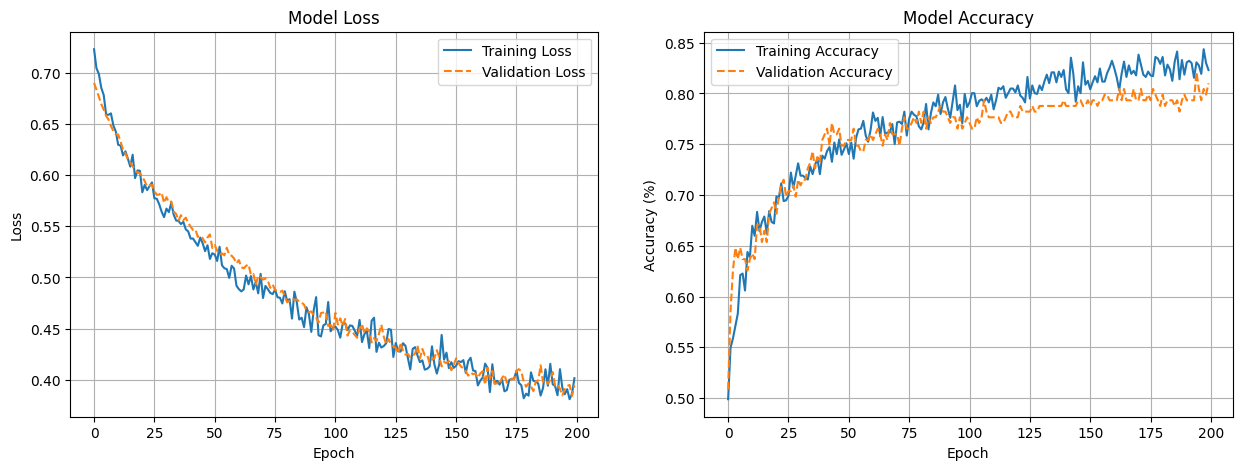

In [19]:
train(train_loader=train_loader, model=fcnn, optimizer=optimizer, loss_function=loss_function, num_epochs=200, patience=30)

# 5.0 Model Evaluation

#### Fully Connected Neuron Network

In [53]:
def evaluate(data_loader, net):
    correct = 0
    total = 0

    # Set the model to evaluation mode
    net.eval()

    # Disable gradient computation
    with torch.inference_mode():

        # Repeat for all batch data
         for x_batch, y_batch in data_loader:

            # transfer to GPU
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            # predict class scores
            y_hat = net(x_batch)
            y_hat = y_hat.squeeze()
            y_pred = (y_hat > 0.5).float()

            # accumulate to total and correct
            total   += y_batch.size(0)
            correct += (y_pred == y_batch).sum().item()

    # compute accuracy
    acc = correct / total
    return acc

In [54]:
fcnn.load_state_dict(torch.load('mlp_latest_norm_best_model.pth'))
fcnn.eval()

FCNN(
  (layer1): Sequential(
    (0): Linear(in_features=51, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.1)
    (3): Dropout(p=0.5, inplace=False)
  )
  (layer2): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.1)
    (3): Dropout(p=0.2, inplace=False)
  )
  (layer3): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.1)
    (3): Dropout(p=0.2, inplace=False)
  )
  (outputlayer): Linear(in_features=32, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

In [55]:
test_acc = evaluate(valid_loader, fcnn)
print(f"t_acc = {test_acc * 100:.2f}%")

t_acc = 79.89%


In [56]:
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in valid_loader:
        inputs = inputs.to(device)
        outputs = fcnn(inputs)
        predicted = (outputs > 0.5).squeeze().numpy()
        all_preds.extend(predicted)
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds))


              precision    recall  f1-score   support

           0       0.82      0.76      0.79        88
           1       0.78      0.84      0.81        91

    accuracy                           0.80       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.80      0.80      0.80       179



In [57]:
test_acc = evaluate(test_loader, fcnn)
print(f"t_acc = {test_acc * 100:.2f}%")

t_acc = 78.65%
